# Exploratory Data Analysis

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset

In [2]:
df=pd.read_csv("IMDB_Movie_Data.csv")

## Describing the dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   str    
 2   Genre               1000 non-null   str    
 3   Description         1000 non-null   str    
 4   Director            1000 non-null   str    
 5   Actors              1000 non-null   str    
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), str(5)
memory usage: 93.9 KB


The output above shows the number of rows and columns, the data type of each column, and the count of non-null values. This helps identify missing data and whether the column types are appropriate for analysis.

### Display few rows from dataset

In [4]:
df.head()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


### Identify data types of each column

In [5]:
df.dtypes

Rank                    int64
Title                     str
Genre                     str
Description               str
Director                  str
Actors                    str
Year                    int64
Runtime (Minutes)       int64
Rating                float64
Votes                   int64
Revenue (Millions)    float64
Metascore             float64
dtype: object

### Check for missing values

In [6]:
df.isnull().sum()


Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

### Check for duplicate value and delete if any

In [7]:
print(f"Number of duplicate values = {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

Number of duplicate values = 0


### Create histograms or bar charts for numerical and categorical columns to visualize their distributions.

#### Histograms

Numerical Columns


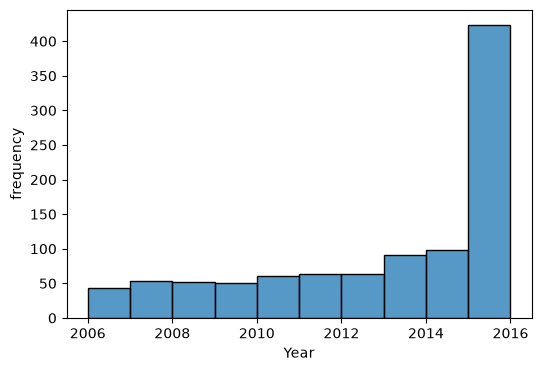

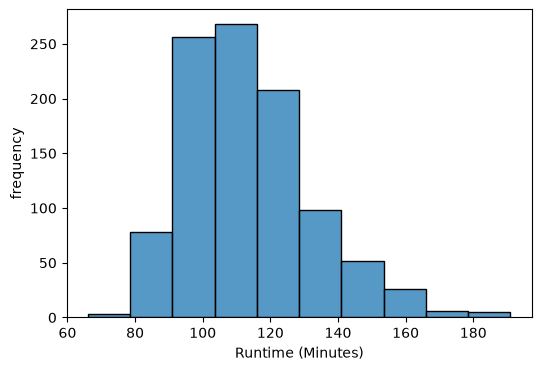

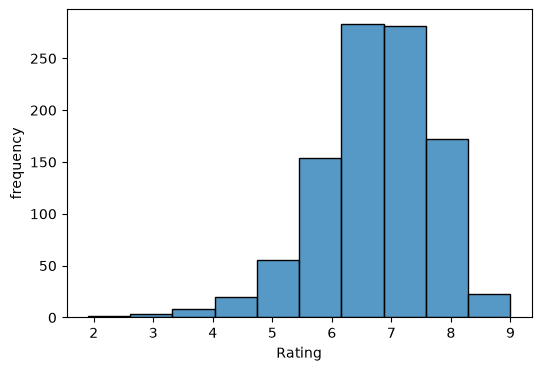

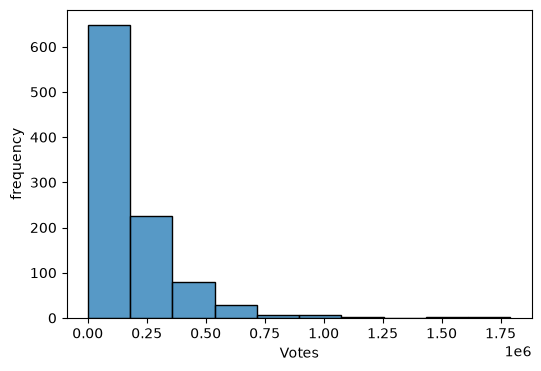

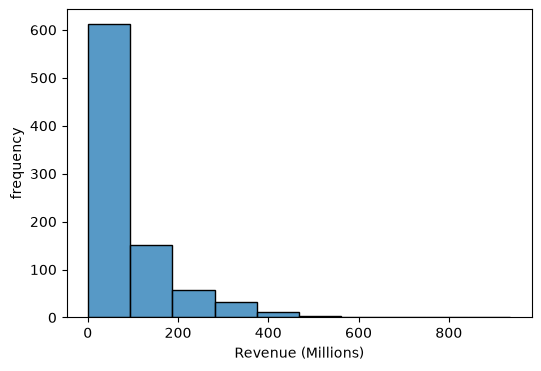

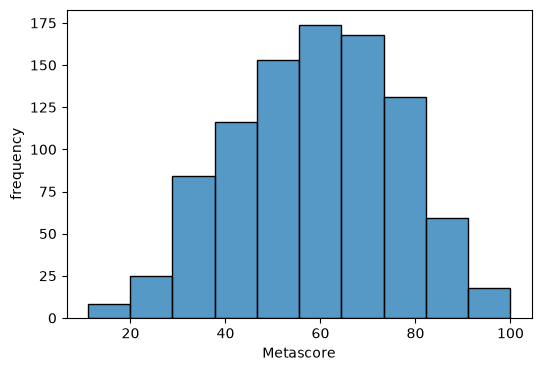

Categorical Columns:


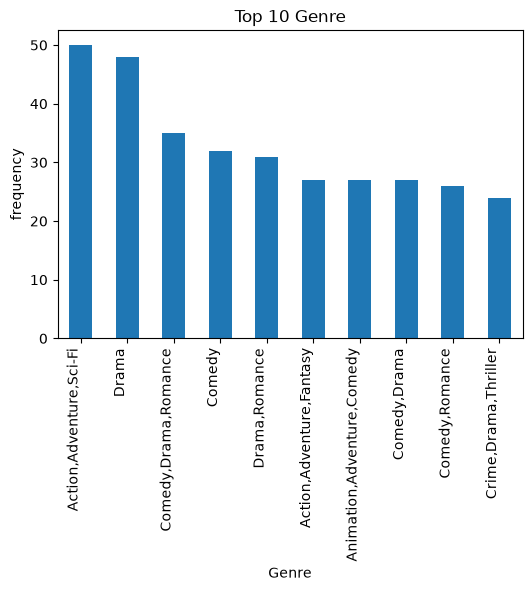

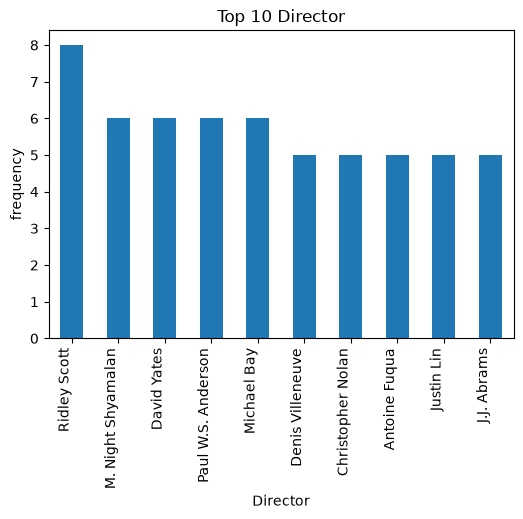

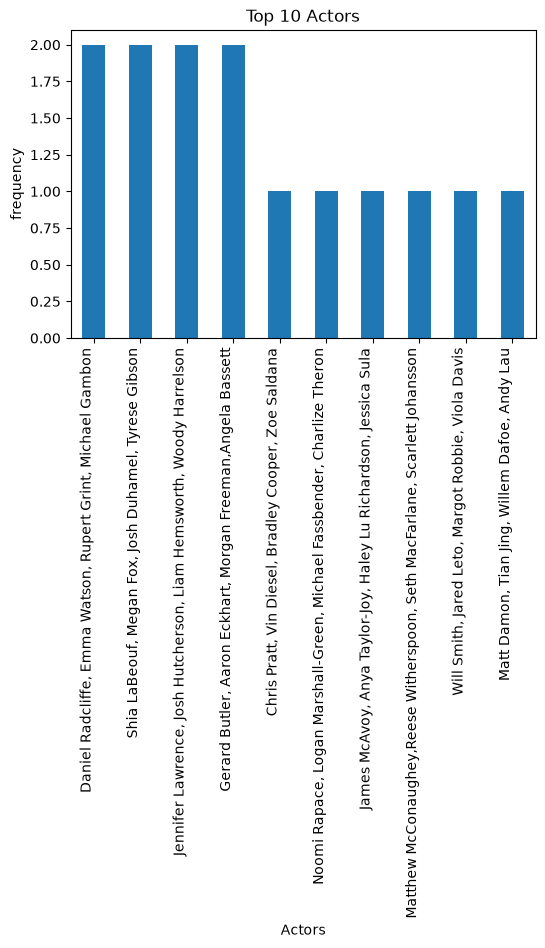

In [8]:
num_col = [
    "Year","Runtime (Minutes)","Rating","Votes","Revenue (Millions)","Metascore"
]
cat_col = [
    "Genre","Director","Actors"
]

print("Numerical Columns")
for col in num_col:
    plt.figure(figsize=(6,4))
    plt.xlabel(col)
    plt.ylabel("frequency")
    sns.histplot(df[col],bins=10)
    plt.show()

print("Categorical Columns:")

for col in cat_col:
    top = df[col].value_counts().nlargest(10)
    top.plot(kind="bar", figsize=(6,4))
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.xticks(rotation=90, ha='right')
    plt.title(f"Top 10 {col}")
    plt.show()

##### Numerical Columns (Histograms)

- **Year** – Heavily skewed toward recent years; most movies are from **2014–2016**, with fewer going back to 2006. The dataset leans recent.
- **Runtime (Minutes)** – Roughly bell-shaped, centered around **100–120 min**, typical for mainstream films; a few long outliers stretch toward 190 min.
- **Rating** – Fairly normal/bell-shaped distribution centered around **6.5–7**, meaning most movies are decently rated, with few very low or very high scores.
- **Votes** – Strongly **right-skewed**: most movies have relatively few votes, but a small number of blockbuster/popular titles have very high vote counts (long tail).
- **Revenue (Millions)** – Also **right-skewed**: most films earn modest revenue, while a handful of big hits pull in very high box office (up to ~$937M), pulling the mean (~$83M) well above the median (~$48M).
- **Metascore** – Close to normally distributed, centered around **55–60**, similar spread to Rating but on the critic-review scale.

##### Categorical Columns (Top 10 Bar Charts)

- **Genre** – Dominated by combination genres like *Action/Adventure/Sci-Fi* and *Drama*; multi-genre labeling means "Genre" is really a mix of tags rather than clean categories.
- **Director** – No single director dominates; top directors (Ridley Scott, Michael Bay, etc.) each directed only 5–8 films, showing a long tail of many directors with just 1–2 movies.
- **Actors** – Almost every actor combination is unique (frequency of 1–2), so this column has very high cardinality and isn't very useful for frequency-based analysis as-is (would need to split into individual actors).

##### Data Quality Note

`Revenue (Millions)` has **128 missing values** and `Metascore` has **64 missing** — worth handling (impute or drop) before further analysis.

### Generate scatter plots or pair plots to explore relationships between pairs of numerical variables.

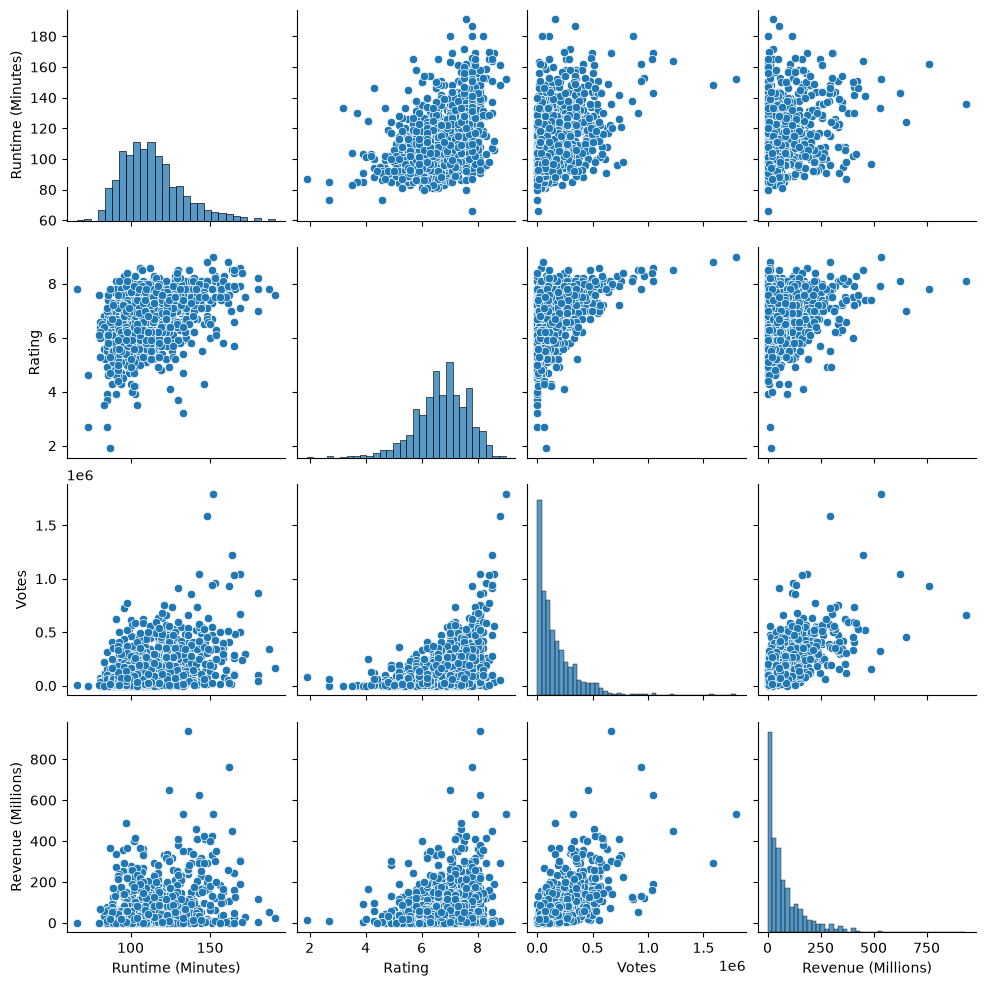

In [9]:
sns.pairplot(df[[
    "Runtime (Minutes)",
    "Rating",
    "Votes",
    "Revenue (Millions)",
]])
plt.show()

##### Pairplot (Runtime, Rating, Votes, Revenue)

- **Diagonal (distributions)** – Confirms earlier histograms: Runtime and Rating are roughly bell-shaped, while Votes and Revenue are strongly right-skewed with long tails of high-performing outliers.
- **Votes vs Revenue** – Shows the clearest upward trend among all pairs, visually confirming the 0.64 correlation — higher-voted movies cluster toward higher revenue.
- **Rating vs Votes / Rating vs Revenue** – Mild upward trend with a lot of scatter, indicating a weak positive relationship — higher ratings don't strongly guarantee more votes or revenue.
- **Runtime vs others** – Points are widely scattered with no clear pattern, confirming runtime has little predictive relationship with rating, votes, or revenue.
- **Outliers** – A handful of points with very high Votes/Revenue stand out from the main cluster in every plot involving those two variables, consistent with a few blockbuster films skewing the data.

### Create a heatmap of the correlation matrix

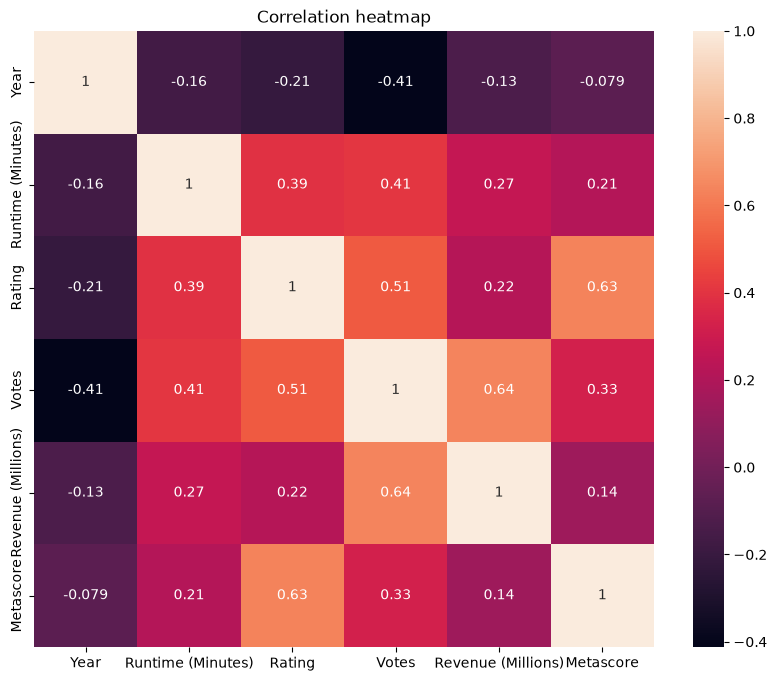

In [10]:
corr_matrix = df[num_col].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot = True)
plt.title("Correlation heatmap")
plt.show()

##### Correlation Heatmap

- **Votes & Revenue (0.64)** – The strongest relationship in the dataset: movies with more votes (more popular/watched) tend to earn more revenue.
- **Rating & Metascore (0.63)** – Moderately strong positive correlation: audience ratings and critic scores generally agree, though not perfectly.
- **Rating & Votes (0.39)**, **Runtime & Votes (0.41)** – Weak-to-moderate positive links: better-rated and longer movies tend to attract somewhat more votes.
- **Runtime & Revenue (0.27)**, **Runtime & Rating (0.39)** – Longer movies tend to be rated slightly higher and earn modestly more.
- **Year** – Negatively correlated with almost everything (Votes: -0.41, Rating: -0.21, Revenue: -0.13), suggesting older movies in this dataset tend to have more accumulated votes and slightly higher ratings — likely because they've had more time to collect votes/reputation, not necessarily because they're "better."
- **Metascore & Revenue (0.14)**, **Metascore & Runtime (0.21)** – Weak correlations: critic score is largely independent of runtime and box office earnings.

Overall, no variables are strongly linearly related except Votes–Revenue and Rating–Metascore; most correlations are weak, meaning these features largely carry independent information.